# checking scaled data

In [1]:
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt

In [2]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [3]:
print(uwrf_train['PSFC'].values[0])

[[ 98884.15   98726.51   98580.4   ... 101911.55  101913.734 101916.45 ]
 [ 99104.69   98928.39   98747.22  ... 101913.65  101915.76  101918.375]
 [ 99175.03   98901.31   98702.31  ... 101916.016 101918.06  101920.64 ]
 ...
 [ 96730.945  96918.86   97277.87  ... 101573.    101826.2   101937.445]
 [ 97292.52   97286.22   97401.516 ... 101548.4   101745.664 101892.586]
 [ 97840.29   97583.75   97703.04  ... 101471.625 101617.375 101803.26 ]]


In [4]:
var_list = ['T2']
pred_var_list = ['PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']

for var in var_list:
    # High resolution (uWRF) data
    var_hr_train = uwrf_train[var]
    var_hr_val = uwrf_val[var]
    var_hr_test = uwrf_test[var]

    # Combine predictor variables
    pred_var_hr_train = np.stack([uwrf_train[p] for p in pred_var_list], axis=1)
    pred_var_hr_val = np.stack([uwrf_val[p] for p in pred_var_list], axis=1)
    pred_var_hr_test = np.stack([uwrf_test[p] for p in pred_var_list], axis=1)

    # Low resolution (NAM) data
    var_lr_train = nam_train[var]
    var_lr_val = nam_val[var]
    var_lr_test = nam_test[var]
    
    #Combine LR predictor variables
    pred_var_lr_train = np.stack([nam_train[p] for p in pred_var_list], axis=1)
    pred_var_lr_val = np.stack([nam_val[p] for p in pred_var_list], axis=1)
    pred_var_lr_test = np.stack([nam_test[p] for p in pred_var_list], axis=1)

    # Normalize
    var_scaler_train = dds.TorchStandardScaler(axis=None)
    var_scaler_train.fit(var_hr_train)

    pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
    pred_var_scaler_train.fit(pred_var_hr_train)

    # High resolution (targets)
    y_train = var_scaler_train.transform(var_hr_train)
    y_val = var_scaler_train.transform(var_hr_val)
    y_test = var_scaler_train.transform(var_hr_test)

    # Low resolution (inputs)
    x_train = var_scaler_train.transform(var_lr_train)
    x_val = var_scaler_train.transform(var_lr_val)
    x_test = var_scaler_train.transform(var_lr_test)

    y_train = np.expand_dims(y_train, axis=1)
    y_val = np.expand_dims(y_val, axis=1)
    y_test = np.expand_dims(y_test, axis=1)


    x_train = np.expand_dims(x_train, axis=1)
    x_val = np.expand_dims(x_val, axis=1)
    x_test = np.expand_dims(x_test, axis=1)

    # Create one scaler per predictor channel
    pred_var_scalers = []
    x_z_train_list, x_z_val_list, x_z_test_list = [], [], []
    y_z_train_list, y_z_val_list, y_z_test_list = [], [], []
    
    for i in range(pred_var_hr_train.shape[1]):
        scaler = dds.TorchStandardScaler(axis=None)
        scaler.fit(pred_var_hr_train[:, i])
        pred_var_scalers.append(scaler)
    
        y_z_train_list.append(np.expand_dims(scaler.transform(pred_var_hr_train[:, i]), axis=1))
        y_z_val_list.append(np.expand_dims(scaler.transform(pred_var_hr_val[:, i]), axis=1))
        y_z_test_list.append(np.expand_dims(scaler.transform(pred_var_hr_test[:, i]), axis=1))
    
        x_z_train_list.append(np.expand_dims(scaler.transform(pred_var_lr_train[:, i]), axis=1))
        x_z_val_list.append(np.expand_dims(scaler.transform(pred_var_lr_val[:, i]), axis=1))
        x_z_test_list.append(np.expand_dims(scaler.transform(pred_var_lr_test[:, i]), axis=1))
    
    # Concatenate all predictor channels along channel axis
    pred_var_train = np.concatenate(y_z_train_list, axis=1)
    pred_var_val = np.concatenate(y_z_val_list, axis=1)
    pred_var_test = np.concatenate(y_z_test_list, axis=1)

In [5]:
print(pred_var_train.shape)
print(pred_var_val.shape)

(2697, 5, 120, 120)
(578, 5, 120, 120)


In [6]:
print(x_train.shape)
print(y_train.shape)

(2697, 1, 40, 40)
(2697, 1, 120, 120)


In [7]:
import xarray as xr

# Load your datasets
hr_ds = uwrf_train
lr_ds = nam_train

# Check coordinate variables
print(hr_ds)
print(lr_ds)


<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 58kB ...
    longitude  (y, x) float32 58kB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB 279.1 279.1 279.0 ... 286.9 287.1
    PSFC       (time, y, x) float32 155MB 9.888e+04 9.873e+04 ... 1.01e+05
    U10        (time, y, x) float32 155MB -1.981 -2.044 -2.099 ... 1.553 1.525
    V10        (time, y, x) float32 155MB 2.25 2.206 2.152 ... 3.783 1.914 1.966
    SWDOWN     (time, y, x) float32 155MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    PBLH       (time, y, x) float32 155MB 0.0 0.0 0.0 0.0 ... 332.3 332.1 372.5
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00

In [8]:
print(y_train.shape)
for i, arr in enumerate(y_z_train_list):
    print(f"x_z_train_list[{i}] shape: {arr.shape}")



(2697, 1, 120, 120)
x_z_train_list[0] shape: (2697, 1, 120, 120)
x_z_train_list[1] shape: (2697, 1, 120, 120)
x_z_train_list[2] shape: (2697, 1, 120, 120)
x_z_train_list[3] shape: (2697, 1, 120, 120)
x_z_train_list[4] shape: (2697, 1, 120, 120)


In [9]:
print(y_train[0])

[[[0.86676085 0.8643416  0.8624398  ... 1.5552435  1.561223   1.5663536 ]
  [0.8739479  0.87107754 0.86799484 ... 1.5419264  1.5470171  1.5513558 ]
  [0.88101554 0.8777073  0.8733729  ... 1.528521   1.5322583  1.5355664 ]
  ...
  [0.35415056 0.34543765 0.3367071  ... 0.53478616 0.5431364  0.551009  ]
  [0.36453086 0.35651234 0.34811345 ... 0.5377893  0.54444116 0.55036324]
  [0.37163386 0.3645574  0.35663176 ... 0.5388684  0.54388386 0.54818285]]]


In [10]:
psfc_index = pred_var_list.index('PBLH')
print(psfc_index)

4


In [13]:
uwrf_train

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 58kB ...
    longitude  (y, x) float32 58kB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB 279.1 279.1 279.0 ... 286.9 287.1
    PSFC       (time, y, x) float32 155MB 9.888e+04 9.873e+04 ... 1.01e+05
    U10        (time, y, x) float32 155MB -1.981 -2.044 -2.099 ... 1.553 1.525
    V10        (time, y, x) float32 155MB 2.25 2.206 2.152 ... 3.783 1.914 1.966
    SWDOWN     (time, y, x) float32 155MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    PBLH       (time, y, x) float32 155MB 0.0 0.0 0.0 0.0 ... 332.3 332.1 372.5
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [19]:
ds = uwrf_train

print(ds['latitude'].shape)
print(ds['longitude'].shape)


(120, 120)
(120, 120)


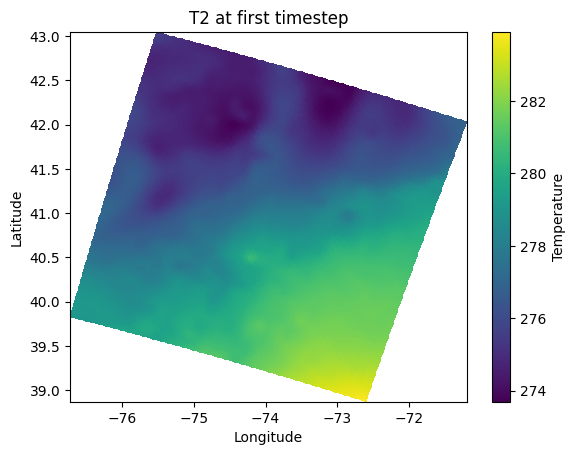

In [23]:
import matplotlib.pyplot as plt


plt.figure()
plt.pcolormesh(ds.longitude, ds.latitude, ds.T2.isel(time=0), shading='auto')
plt.title('T2 at first timestep')
plt.colorbar(label='Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [24]:
print(ds.time)

<xarray.DataArray 'time' (time: 2697)> Size: 22kB
array(['2019-01-01T00:00:00.000000000', '2019-01-01T03:00:00.000000000',
       '2019-01-01T06:00:00.000000000', ..., '2019-04-14T00:00:00.000000000',
       '2019-04-14T03:00:00.000000000', '2019-04-14T03:00:00.000000000'],
      shape=(2697,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Attributes:
    FieldType:    104
    MemoryOrder:  0  
    description:  minutes since 2019-01-01 00:00:00
    stagger:      


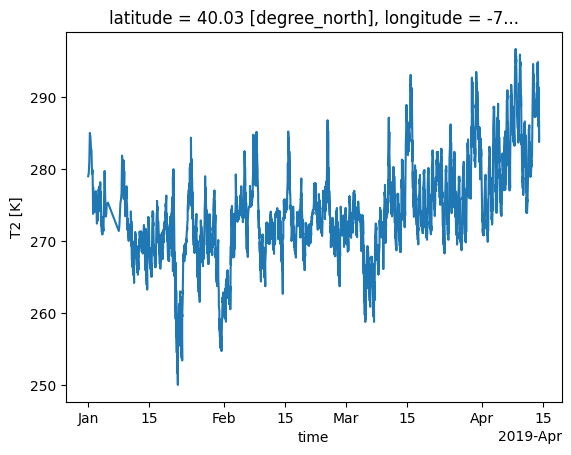

In [25]:
ds.T2.sel(x=10, y=10).plot()


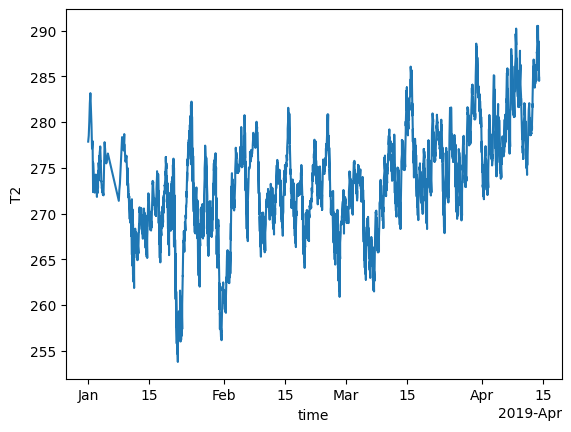

In [26]:
ds.T2.mean(dim=['x', 'y']).plot()


{'FieldType': np.int32(104), 'MemoryOrder': 'XY ', 'description': 'TEMP at 2 M', 'units': 'K', 'stagger': ''}
237.51517 300.81238


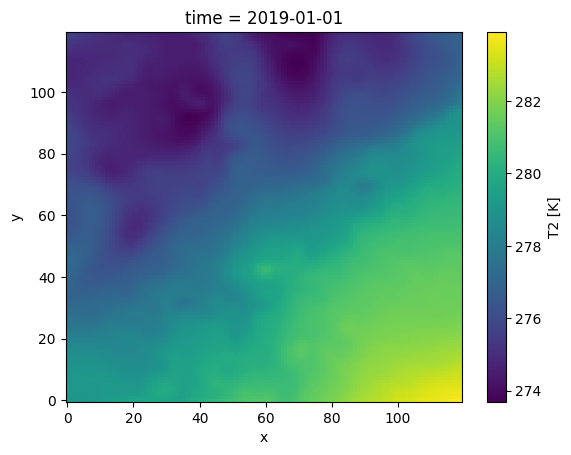

In [27]:
print(ds['T2'].attrs)
print(ds['T2'].min().values, ds['T2'].max().values)
ds['T2'].isel(time=0).plot()


Text(0.5, 1.0, 'T2 Distribution')

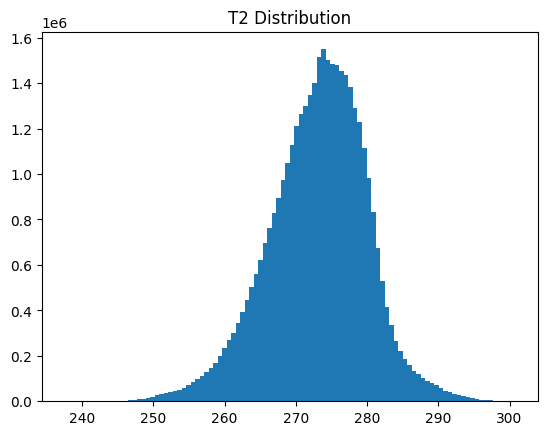

In [28]:
ds['T2'].values.flatten()
plt.hist(ds['T2'].values.flatten(), bins=100)
plt.title('T2 Distribution')


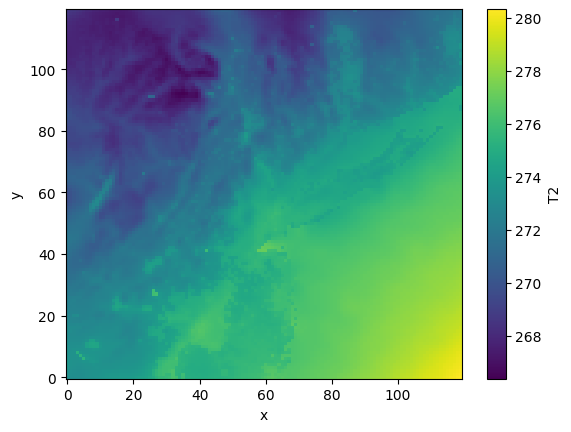

In [31]:
ds['T2'].mean(dim='time').plot()

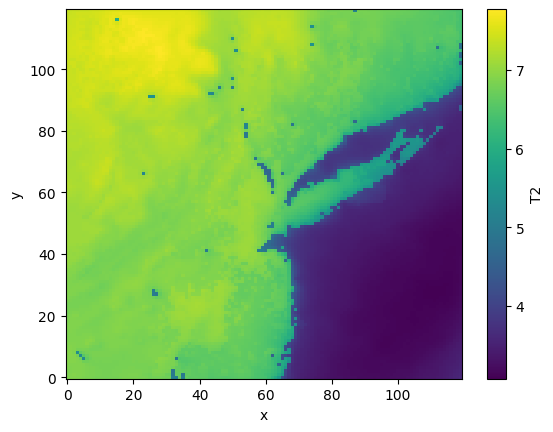

In [30]:
ds['T2'].std(dim='time').plot()

In [32]:
print(ds.latitude.min(), ds.latitude.max())
print(ds.longitude.min(), ds.longitude.max())


<xarray.DataArray 'latitude' ()> Size: 4B
array(38.88588, dtype=float32) <xarray.DataArray 'latitude' ()> Size: 4B
array(43.029186, dtype=float32)
<xarray.DataArray 'longitude' ()> Size: 4B
array(-76.70499, dtype=float32) <xarray.DataArray 'longitude' ()> Size: 4B
array(-71.21628, dtype=float32)


In [33]:
np.isnan(ds['T2']).sum().values


array(0)